# pyUDE Quickstart

This notebook demonstrates the three main model types in pyUDE:

1. **NODE** — Neural ODE (learns all dynamics from data)
2. **CustomDerivatives** — Hybrid UDE (known mechanistic terms + neural network)
3. **CustomDifferences** — Discrete-time hybrid UDE
4. **Inspecting dynamics** — Extracting the learned RHS and using it with scipy

Each section follows the same pattern: generate synthetic data → build model → train → visualize.

## 0. Setup

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyUDE as ude

print(f"pyUDE version: {ude.__version__}")
torch.manual_seed(42)
np.random.seed(42)

pyUDE version: 0.0.2


In [2]:
# Helper: generate Lotka-Volterra data via scipy (accurate ground truth)
def make_lotka_volterra(
    t_end=12.0, n_points=120,
    u0=(10.0, 5.0),
    alpha=1.0, beta=0.1, delta=0.075, gamma=1.5,
    noise=0.05,
):
    from scipy.integrate import solve_ivp
    def rhs(t, u):
        prey, pred = u
        return [alpha * prey - beta * prey * pred,
                delta * prey * pred - gamma * pred]
    sol = solve_ivp(rhs, [0, t_end], list(u0),
                    t_eval=np.linspace(0, t_end, n_points),
                    method="RK45", rtol=1e-8, atol=1e-10)
    rng = np.random.default_rng(42)
    prey = np.maximum(sol.y[0] + noise * rng.standard_normal(n_points), 1e-3)
    pred = np.maximum(sol.y[1] + noise * rng.standard_normal(n_points), 1e-3)
    return pd.DataFrame({"time": sol.t, "prey": prey, "predator": pred})


# Helper: generate exponential decay data
def make_decay(t_end=5.0, n_points=60, rate=0.5, noise=0.0):
    t = np.linspace(0, t_end, n_points)
    x = np.exp(-rate * t) + noise * np.random.randn(n_points)
    return pd.DataFrame({"time": t, "x": x})


# Helper: generate logistic map data
def make_logistic_map(n_steps=120, r=3.6, x0=0.5):
    x = x0
    rows = []
    for i in range(n_steps):
        rows.append((float(i), x))
        x = r * x * (1 - x)
    return pd.DataFrame(rows, columns=["time", "x"])


print("Data generators ready.")

Data generators ready.


---
## 1. Neural ODE (NODE)

A **NODE** learns the full dynamics `du/dt = NN(u)` from data — no prior knowledge required.

We use exponential decay `dx/dt = -0.5 x` as a simple test case.

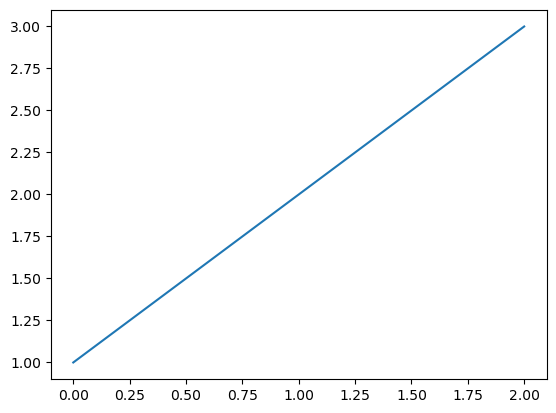

In [3]:
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot([1, 2, 3])
from IPython.display import display; display(fig); plt.close(fig)

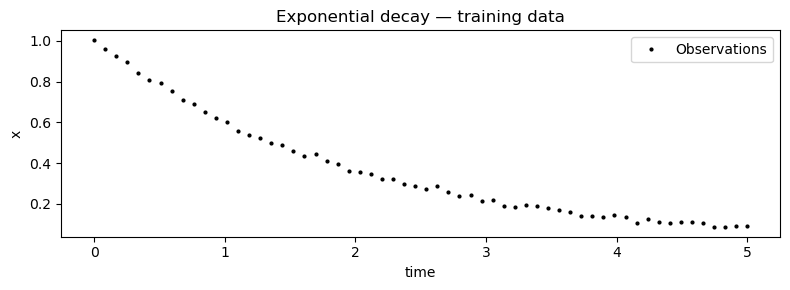

In [4]:
from IPython.display import display

decay_data = make_decay(noise=0.01)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(decay_data["time"], decay_data["x"], "k.", ms=4, label="Observations")
ax.set(xlabel="time", ylabel="x", title="Exponential decay — training data")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

In [5]:
node = ude.NODE(
    decay_data,
    hidden_units=32,
    hidden_layers=2,
)
node.train(
    loss="simulation",
    optimizer="adam",
    learning_rate=5e-3,
    epochs=1000,
    log_interval=200,
    solver="dopri5",
    patience=200,
)

Epoch   200/1000  loss=0.000114
Epoch   400/1000  loss=0.000108
Epoch   600/1000  loss=0.000103
Epoch   800/1000  loss=0.000097
Epoch  1000/1000  loss=0.000092


NODE(states=1, columns=['x'], device='cpu', trained)

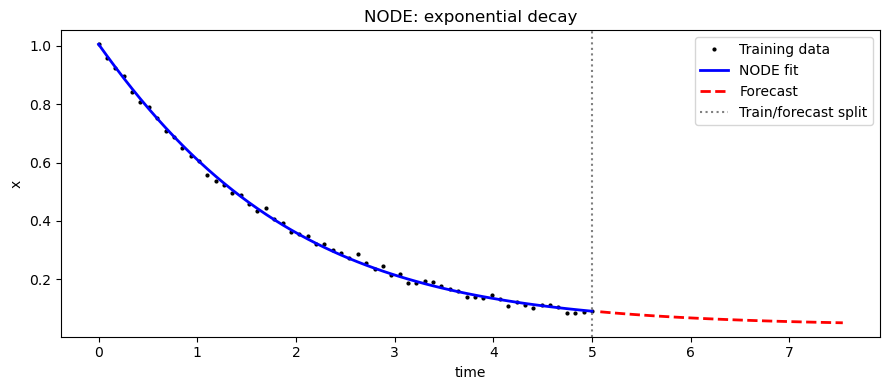

In [6]:
from torchdiffeq import odeint

t_train, u_train, _ = node._get_training_tensors()
with torch.no_grad():
    u_fit = odeint(node._ode_func, u_train[0], t_train, method="rk4").numpy()

forecast_df = node.forecast(steps=30)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(decay_data["time"], decay_data["x"], "k.", ms=4, label="Training data")
ax.plot(t_train.numpy(), u_fit[:, 0], "b-", lw=2, label="NODE fit")
ax.plot(forecast_df["time"], forecast_df["x"], "r--", lw=2, label="Forecast")
ax.axvline(float(t_train[-1]), color="gray", ls=":", label="Train/forecast split")
ax.set(xlabel="time", ylabel="x", title="NODE: exponential decay")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

### NODE on Lotka-Volterra (two-state system)

In [9]:
lv_data = make_lotka_volterra()

node_lv = ude.NODE(lv_data, hidden_units=64, hidden_layers=3)

# Stage 1: derivative-matching warm-up (no ODE integration — cheap and fast)
node_lv.train(
    loss="derivative_matching",
    optimizer="adam",
    learning_rate=3e-3,
    epochs=800,
    log_interval=200,
    patience=300,
)

Epoch   200/800  loss=4.508603
Epoch   400/800  loss=0.472188
Epoch   600/800  loss=0.328371
Epoch   800/800  loss=0.293833


NODE(states=2, columns=['prey', 'predator'], device='cpu', trained)

In [ ]:
# Stage 2: simulation fine-tune (coarse learning rate)
node_lv.train(
    loss="simulation",
    learning_rate=1e-3,
    epochs=2000,
    log_interval=400,
    solver="rk4",
    patience=400,
    max_grad_norm=5.0,
)

# Stage 3: final polish (fine learning rate)
node_lv.train(
    loss="simulation",
    learning_rate=1e-4,
    epochs=1000,
    log_interval=200,
    solver="dopri5",
    patience=300,
    max_grad_norm=2.0,
)

KeyboardInterrupt: 

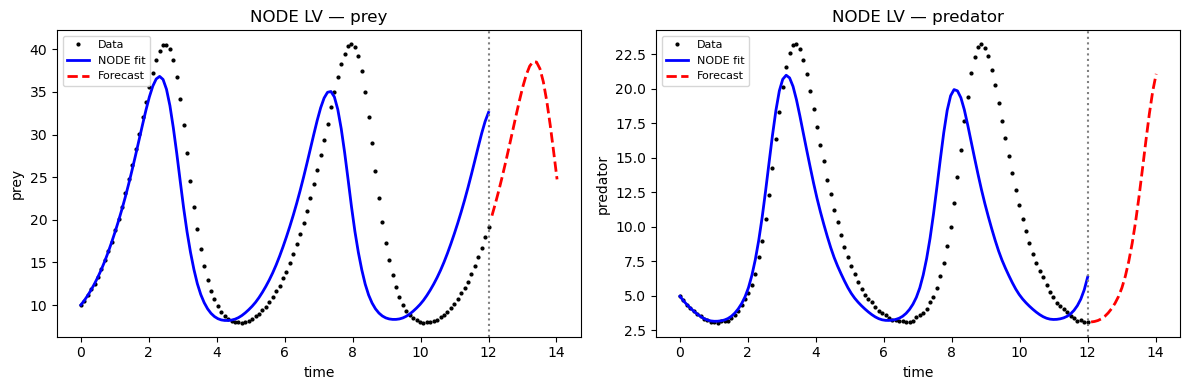

In [10]:
t_lv, u_lv, _ = node_lv._get_training_tensors()
with torch.no_grad():
    u_fit_lv = odeint(node_lv._ode_func, u_lv[0], t_lv, method="rk4").numpy()

forecast_lv = node_lv.forecast(steps=20)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, fit_col in zip(axes, ["prey", "predator"], [0, 1]):
    ax.plot(lv_data["time"], lv_data[col], "k.", ms=4, label="Data")
    ax.plot(t_lv.numpy(), u_fit_lv[:, fit_col], "b-", lw=2, label="NODE fit")
    ax.plot(forecast_lv["time"], forecast_lv[col], "r--", lw=2, label="Forecast")
    ax.axvline(float(t_lv[-1]), color="gray", ls=":")
    ax.set(xlabel="time", ylabel=col, title=f"NODE LV — {col}")
    ax.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close(fig)

---
## 2. Hybrid UDE — CustomDerivatives

We know that prey growth is exponential (`+alpha * prey`) and predators die without prey (`-delta * pred`), but the **interaction terms** (predation, conversion efficiency) are unknown. We encode what we know and let the neural network learn the rest.

In [ ]:
def lv_known(u, p, t):
    """Known terms: linear prey growth + predator death."""
    prey, pred = u[0], u[1]
    return torch.stack([
        p["alpha"] * prey,    # prey growth (known)
        -p["delta"] * pred,   # predator death (known)
    ])


lv_data_train = make_lotka_volterra()

ude_model = ude.CustomDerivatives(
    lv_data_train,
    known_dynamics=lv_known,
    init_params={"alpha": 0.5, "delta": 0.8},   # intentionally far from truth
    hidden_units=32,
    hidden_layers=2,
)

# Stage 1: derivative-matching warm-up
ude_model.train(
    loss="derivative_matching",
    learning_rate=5e-3,
    epochs=600,
    log_interval=200,
    patience=200,
)
print("After warm-up:", ude_model.get_params())

# Stage 2: simulation fine-tune
ude_model.train(
    loss="simulation",
    learning_rate=1e-3,
    epochs=3000,
    log_interval=500,
    solver="dopri5",
    patience=600,
    max_grad_norm=5.0,
)
print("After fine-tune:", ude_model.get_params())

# Stage 3: low-LR polish
ude_model.train(
    loss="simulation",
    learning_rate=1e-4,
    epochs=1000,
    log_interval=200,
    solver="dopri5",
    patience=300,
    max_grad_norm=1.0,
)
print("Final params (true: alpha=1.0, delta=1.5):", ude_model.get_params())

In [ ]:
# Learned mechanistic parameters (true: alpha=1.0, delta=1.5)
params = ude_model.get_params()
print("Learned mechanistic parameters:")
for k, v in params.items():
    print(f"  {k} = {v:.4f}")

Learned mechanistic parameters:
  alpha = 0.7146
  delta = 1.1294


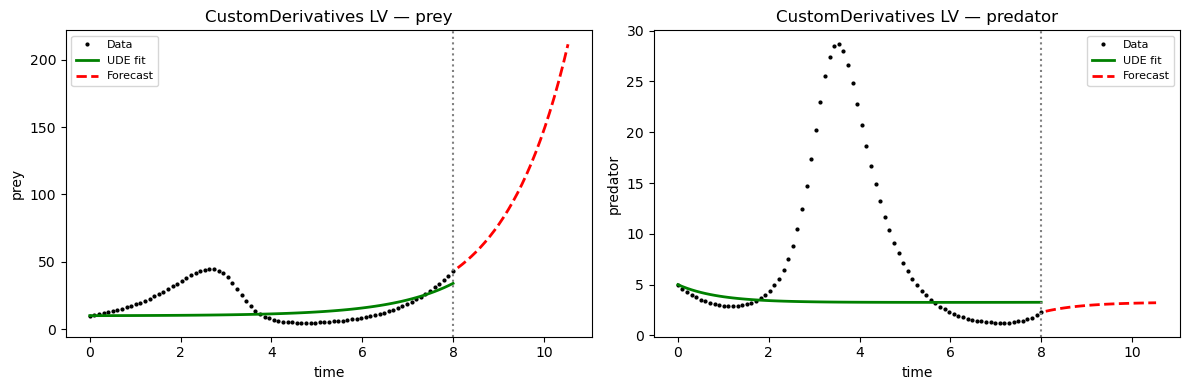

In [ ]:
t_ude, u_ude, _ = ude_model._get_training_tensors()
with torch.no_grad():
    u_fit_ude = odeint(ude_model._ode_func, u_ude[0], t_ude, method="rk4").numpy()

forecast_ude = ude_model.forecast(steps=25)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, fit_col in zip(axes, ["prey", "predator"], [0, 1]):
    ax.plot(lv_data_train["time"], lv_data_train[col], "k.", ms=4, label="Data")
    ax.plot(t_ude.numpy(), u_fit_ude[:, fit_col], "g-", lw=2, label="UDE fit")
    ax.plot(forecast_ude["time"], forecast_ude[col], "r--", lw=2, label="Forecast")
    ax.axvline(float(t_ude[-1]), color="gray", ls=":")
    ax.set(xlabel="time", ylabel=col, title=f"CustomDerivatives LV — {col}")
    ax.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close(fig)

### Derivative-matching as a warm-up strategy

A two-stage approach that works well for strongly nonlinear systems:

1. **Warm-up** with derivative-matching loss — no ODE integration required; trains the network to output correct slopes at each observed point.
2. **Fine-tune** with simulation loss — integrates the full trajectory and forces the network to be correct everywhere, not just at data points.

This avoids the instability of starting simulation training from random weights on a nonlinear oscillator.

In [ ]:
ude_dm = ude.CustomDerivatives(
    lv_data_train,
    known_dynamics=lv_known,
    init_params={"alpha": 1.0, "delta": 1.5},
    hidden_units=32,
    hidden_layers=2,
)

# Stage 1: derivative-matching warm-up
ude_dm.train(
    loss="derivative_matching",
    learning_rate=2e-3,
    epochs=800,
    log_interval=200,
    patience=300,
)
print("Params after warm-up:", ude_dm.get_params())

# Stage 2: simulation fine-tune from warm-up weights
ude_dm.train(
    loss="simulation",
    learning_rate=5e-4,
    epochs=2000,
    log_interval=400,
    solver="dopri5",
    patience=500,
    max_grad_norm=3.0,
)
print("Final params (DM → simulation):", ude_dm.get_params())

---
## 3. Discrete-time UDE — CustomDifferences

The **logistic map** `x[n+1] = r * x[n] * (1 - x[n])` is a classic discrete-time system. We know the logistic structure but treat `r` as an unknown parameter, and add a neural network for residual terms.

In [ ]:
map_data = make_logistic_map(n_steps=120, r=3.6, x0=0.5)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(map_data["time"], map_data["x"], "k.-", ms=4, lw=0.5)
ax.set(xlabel="step", ylabel="x", title="Logistic map (r=3.6) — training data")
plt.tight_layout()
display(fig)
plt.close(fig)

In [ ]:
def logistic_known(u, p, t):
    """Known part of the logistic map."""
    return p["r"] * u * (1 - u)


diff_model = ude.CustomDifferences(
    map_data,
    known_map=logistic_known,
    init_params={"r": 3.0},   # intentionally off from true r=3.6
    hidden_units=32,
    hidden_layers=2,
)

# Stage 1: high LR — let scalar r move quickly
diff_model.train(optimizer="adam", learning_rate=3e-3, epochs=500,
                 log_interval=100, patience=150, max_grad_norm=5.0)
print(f"Stage 1: r = {diff_model.get_params()['r']:.4f}")

# Stage 2: medium LR
diff_model.train(optimizer="adam", learning_rate=5e-4, epochs=1000,
                 log_interval=200, patience=300, max_grad_norm=2.0)
print(f"Stage 2: r = {diff_model.get_params()['r']:.4f}")

# Stage 3: fine LR polish
diff_model.train(optimizer="adam", learning_rate=5e-5, epochs=1000,
                 log_interval=200, patience=300, max_grad_norm=1.0)
print(f"Final:   r = {diff_model.get_params()['r']:.4f}  (true: 3.6)")

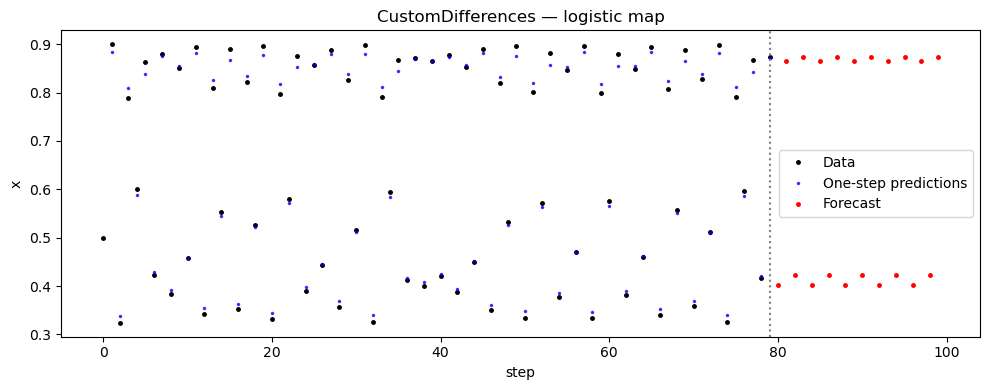

In [ ]:
import torch

t_map, u_map, _ = diff_model._get_training_tensors()
p = {k: v for k, v in diff_model._param_dict.items()}
preds = []
with torch.no_grad():
    for i in range(len(t_map) - 1):
        u_next = diff_model._known_map(u_map[i], p, t_map[i]) + diff_model._network_module(u_map[i])
        preds.append(float(u_next.item()))

forecast_map = diff_model.forecast(steps=20)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(map_data["time"], map_data["x"], "k.", ms=5, label="Data")
ax.plot(map_data["time"][1:], preds, "b.", ms=3, alpha=0.7, label="One-step predictions")
ax.plot(forecast_map["time"], forecast_map["x"], "r.", ms=5, label="Forecast")
ax.axvline(float(t_map[-1]), color="gray", ls=":")
ax.set(xlabel="step", ylabel="x", title="CustomDifferences — logistic map")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

---
## 4. Inspecting learned dynamics with `get_right_hand_side()`

`get_right_hand_side()` extracts the learned ODE as a numpy-compatible function, making it interoperable with scipy and other tools.

In [ ]:
from scipy.integrate import odeint as scipy_odeint

rhs = ude_model.get_right_hand_side()

u0_np = lv_data_train[["prey", "predator"]].iloc[0].values
t_full = np.linspace(0, 20, 400)
sol = scipy_odeint(rhs, y0=u0_np, t=t_full)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, idx in zip(axes, ["prey", "predator"], [0, 1]):
    ax.plot(lv_data_train["time"], lv_data_train[col], "k.", ms=4, label="Training data")
    ax.plot(t_full, sol[:, idx], "m-", lw=2, label="scipy (get_rhs)")
    ax.axvline(float(t_ude[-1]), color="gray", ls=":", label="End of training")
    ax.set(xlabel="time", ylabel=col, title=f"scipy integration — {col}")
    ax.legend(fontsize=8)
plt.tight_layout()
display(fig)
plt.close(fig)

### Phase portrait of learned dynamics

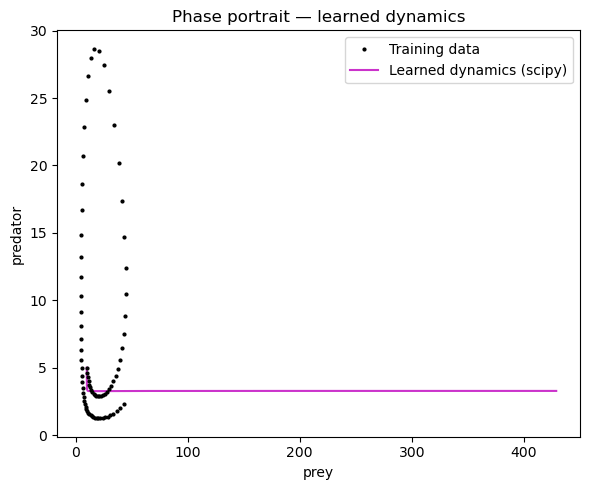

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(lv_data_train["prey"], lv_data_train["predator"], "k.", ms=4, label="Training data", zorder=3)
ax.plot(sol[:, 0], sol[:, 1], "m-", lw=1.5, alpha=0.8, label="Learned dynamics (scipy)")
ax.set(xlabel="prey", ylabel="predator", title="Phase portrait — learned dynamics")
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

---
## Summary

| Model | Use when | Key method |
|-------|----------|------------|
| `NODE` | No prior knowledge of dynamics | `train(loss="simulation")` |
| `CustomDerivatives` | Partial mechanistic structure known | `get_params()` for learned parameters |
| `CustomDifferences` | Discrete-time map / difference equation | `train()` with one-step-ahead MSE |

All models expose:
- `.forecast(steps)` → future predictions as a DataFrame
- `.get_right_hand_side()` → numpy-compatible dynamics function